<h1 style="text-align:center;">
   Prescriptive Analysis
</h1>

### 1.Does low bolus insulin lead to hyperglycemia episodes and when daily bolus insulin is low and hyperglycemia percentage is high, what bolus adjustment should be recommended?

In [5]:
%cd "H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files"


H:\Numpy Ninja\Python Hackathon\Team2_ PyQueens_ Python Hackathon _MAY 2026\Team2_ PyQueens_ Python Hackathon _MAY 2026\Final cleaned csv files\Final cleaned csv files


In [2]:
import os
os.getcwd()

'H:\\Numpy Ninja\\Python Hackathon\\Team2_ PyQueens_ Python Hackathon _MAY 2026\\Team2_ PyQueens_ Python Hackathon _MAY 2026\\Final cleaned csv files\\Final cleaned csv files'

In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sn

In [6]:
df=pd.read_csv("Team2_PyQueens_Final_Cleaned_File.csv")
df.head()

,Patient_Id,Time,Glucose,Calories,Heart_Rate,Steps,Basal_Rate,Bolus_Volume_Delivered,Carb_Input
0,HUPA0001P,2018-06-13T18:40:00,332.0,6.36,82.32,34.0,0.09,0.0,0.0
1,HUPA0001P,2018-06-13T18:45:00,326.0,7.73,83.74,0.0,0.09,0.0,0.0
2,HUPA0001P,2018-06-13T18:50:00,330.0,4.75,80.53,0.0,0.09,0.0,0.0
3,HUPA0001P,2018-06-13T18:55:00,324.0,6.36,89.13,20.0,0.09,0.0,0.0
4,HUPA0001P,2018-06-13T19:00:00,306.0,5.15,92.50,0.0,0.08,0.0,0.0


In [7]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')


In [13]:
df['Patient_Id'].unique()


array(['HUPA0001P', 'HUPA0002P', 'HUPA0003P', 'HUPA0004P', 'HUPA0005P',
       'HUPA0006P', 'HUPA0007P', 'HUPA0009P', 'HUPA0010P', 'HUPA0011P',
       'HUPA0014P', 'HUPA0015P', 'HUPA0016P', 'HUPA0017P', 'HUPA0018P',
       'HUPA0019P', 'HUPA0020P', 'HUPA0021P', 'HUPA0022P', 'HUPA0023P',
       'HUPA0024P', 'HUPA0025P', 'HUPA0026P', 'HUPA0027P', 'HUPA0028P'],
      dtype=object)

In [20]:
# -----------------------------
# 1. Define hyperglycemia
# -----------------------------
HYPER_THRESHOLD = 180
df['is_hyper'] = (df['Glucose'] > HYPER_THRESHOLD).astype(int)

In [21]:
# -----------------------------
# 2. Create patient-day summary
# -----------------------------
df['date'] = pd.to_datetime(df['Time']).dt.date

daily = (
    df.groupby(['Patient_Id', 'date'])
      .agg(
          daily_bolus=('Bolus_Volume_Delivered', 'sum'),
          hyper_pct=('is_hyper', 'mean')   # % of readings above 180
      )
      .reset_index()
)
daily

,Patient_Id,date,daily_bolus,hyper_pct
0,HUPA0001P,2018-06-13,3.5,0.312500
1,HUPA0001P,2018-06-14,12.7,0.347222
2,HUPA0001P,2018-06-15,10.3,0.274306
3,HUPA0001P,2018-06-16,10.8,0.256944
4,HUPA0001P,2018-06-17,10.4,0.291667
...,...,...,...,...
1088,HUPA0028P,2022-05-14,0.0,0.152778
1089,HUPA0028P,2022-05-15,0.0,0.277778
1090,HUPA0028P,2022-05-16,28.0,0.062500
1091,HUPA0028P,2022-05-17,11.0,0.305556


In [22]:
# -----------------------------
# 3. Create bolus tertiles
# -----------------------------
daily['bolus_group'] = pd.qcut(
    daily['daily_bolus'],
    q=3,
    labels=['Low Bolus', 'Medium Bolus', 'High Bolus']
)
daily

,Patient_Id,date,daily_bolus,hyper_pct,bolus_group
0,HUPA0001P,2018-06-13,3.5,0.312500,Low Bolus
1,HUPA0001P,2018-06-14,12.7,0.347222,Medium Bolus
2,HUPA0001P,2018-06-15,10.3,0.274306,Low Bolus
3,HUPA0001P,2018-06-16,10.8,0.256944,Low Bolus
4,HUPA0001P,2018-06-17,10.4,0.291667,Low Bolus
...,...,...,...,...,...
1088,HUPA0028P,2022-05-14,0.0,0.152778,Low Bolus
1089,HUPA0028P,2022-05-15,0.0,0.277778,Low Bolus
1090,HUPA0028P,2022-05-16,28.0,0.062500,High Bolus
1091,HUPA0028P,2022-05-17,11.0,0.305556,Low Bolus


In [23]:
# -----------------------------
# 4. Prescriptive rule:
#    If LOW bolus + hyper_pct > 0.30 → recommend adjustment
# -----------------------------
daily['recommendation'] = daily.apply(
    lambda row: (
        "Increase bolus dose or review carb counting"
        if (row['bolus_group'] == 'Low Bolus' and row['hyper_pct'] > 0.30)
        else "No adjustment needed"
    ),
    axis=1
)
daily

,Patient_Id,date,daily_bolus,hyper_pct,bolus_group,recommendation
0,HUPA0001P,2018-06-13,3.5,0.312500,Low Bolus,Increase bolus dose or review carb counting
1,HUPA0001P,2018-06-14,12.7,0.347222,Medium Bolus,No adjustment needed
2,HUPA0001P,2018-06-15,10.3,0.274306,Low Bolus,No adjustment needed
3,HUPA0001P,2018-06-16,10.8,0.256944,Low Bolus,No adjustment needed
4,HUPA0001P,2018-06-17,10.4,0.291667,Low Bolus,No adjustment needed
...,...,...,...,...,...,...
1088,HUPA0028P,2022-05-14,0.0,0.152778,Low Bolus,No adjustment needed
1089,HUPA0028P,2022-05-15,0.0,0.277778,Low Bolus,No adjustment needed
1090,HUPA0028P,2022-05-16,28.0,0.062500,High Bolus,No adjustment needed
1091,HUPA0028P,2022-05-17,11.0,0.305556,Low Bolus,Increase bolus dose or review carb counting


In [25]:

# -----------------------------
# 5. Output prescriptive actions
# -----------------------------
prescriptive_q1 = daily[['Patient_Id', 'date', 'daily_bolus', 'hyper_pct', 'recommendation']]
print("\nPrescriptive Analysis for Q1:")
print(prescriptive_q1.head(10))


Prescriptive Analysis for Q1:
  Patient_Id        date  daily_bolus  hyper_pct  \
0  HUPA0001P  2018-06-13          3.5   0.312500   
1  HUPA0001P  2018-06-14         12.7   0.347222   
2  HUPA0001P  2018-06-15         10.3   0.274306   
3  HUPA0001P  2018-06-16         10.8   0.256944   
4  HUPA0001P  2018-06-17         10.4   0.291667   
5  HUPA0001P  2018-06-18         11.6   0.315972   
6  HUPA0001P  2018-06-19         10.4   0.312500   
7  HUPA0001P  2018-06-20         12.2   0.465278   
8  HUPA0001P  2018-06-21          7.3   0.569444   
9  HUPA0001P  2018-06-22         13.1   0.500000   

                                recommendation  
0  Increase bolus dose or review carb counting  
1                         No adjustment needed  
2                         No adjustment needed  
3                         No adjustment needed  
4                         No adjustment needed  
5  Increase bolus dose or review carb counting  
6  Increase bolus dose or review carb counting  
7   

In [27]:
# ---------------------------------------------------------
# 2. Define glucose thresholds
# ---------------------------------------------------------
def insulin_adjustment(Glucose):
    if Glucose > 350:
        return "Severe hyperglycemia: Increase correction bolus by 30% and check ketones"
    elif Glucose > 300:
        return "Very high glucose: Increase correction bolus by 20–30%"
    elif Glucose > 250:
        return "High glucose: Increase correction bolus by 10–20%"
    elif Glucose > 180:
        return "Mild hyperglycemia: Give correction bolus"
    else:
        return "No adjustment needed"

df['insulin_recommendation'] = df['Glucose'].apply(insulin_adjustment)


In [50]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 3. Compute max glucose per day
daily_actions = (
    df.groupby(['Patient_Id', 'Date'])
      .agg(max_glucose=('Glucose', 'max'))
      .reset_index()
)

# 4. Apply recommendation based on max_glucose
daily_actions['recommendation'] = daily_actions['max_glucose'].apply(insulin_adjustment)

daily_actions

,Patient_Id,Date,max_glucose,recommendation
0,HUPA0001P,2018-06-13,332.0,Very high glucose: Increase correction bolus by 20–30%
1,HUPA0001P,2018-06-14,271.0,High glucose: Increase correction bolus by 10–20%
2,HUPA0001P,2018-06-15,365.0,Severe hyperglycemia: Increase correction bolus by 30% and check ketones
3,HUPA0001P,2018-06-16,270.0,High glucose: Increase correction bolus by 10–20%
4,HUPA0001P,2018-06-17,298.0,High glucose: Increase correction bolus by 10–20%
...,...,...,...,...
1088,HUPA0028P,2022-05-14,208.0,Mild hyperglycemia: Give correction bolus
1089,HUPA0028P,2022-05-15,267.0,High glucose: Increase correction bolus by 10–20%
1090,HUPA0028P,2022-05-16,218.0,Mild hyperglycemia: Give correction bolus
1091,HUPA0028P,2022-05-17,256.0,High glucose: Increase correction bolus by 10–20%


****Insights:****







### 2. Identify sleep disturbance percentage patterns and correlation between sleep disturbance % and glucose values? What interventions should be suggested for patients with high sleep disturbance percentages? ###

In [26]:
df_sleep=pd.read_csv("T1DM_patient_sleep_demographics_with_race.csv")
df_sleep.head()

,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


In [29]:
df_sleep.columns = df_sleep.columns.str.replace('_', ' ').str.title().str.replace(' ', '_')
df_sleep.head()

,Patient_Id,Age,Gender,Race,Average_Sleep_Duration_(Hrs),Sleep_Quality_(1-10),%_With_Sleep_Disturbances
0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,HUPA0002P,49,Male,Hispanic,6.6,4.4,40
2,HUPA0003P,64,Male,Black,5.3,5.2,70
3,HUPA0004P,34,Female,Native American,5.2,6.9,60
4,HUPA0005P,49,Male,Native American,5.8,7.9,30


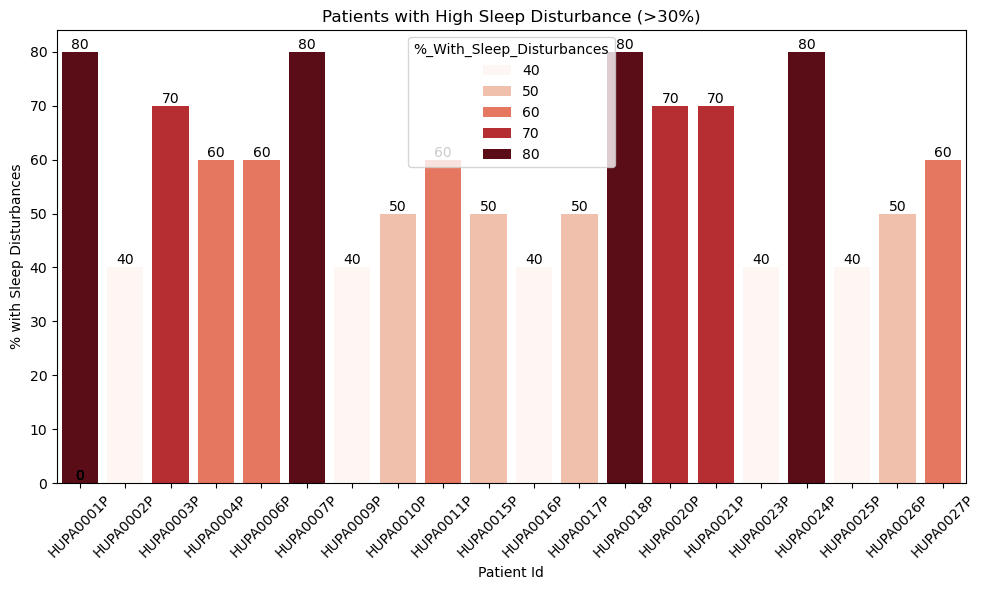

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only high sleep disturbance patients
high_sleep = df_sleep[df_sleep['%_With_Sleep_Disturbances'] > 30]

plt.figure(figsize=(10,6))
ax1=sns.barplot(
    data=high_sleep,
    x='Patient_Id',
    y='%_With_Sleep_Disturbances',
    hue='%_With_Sleep_Disturbances',
    palette='Reds'
)

for p in ax1.patches:
    ax1.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.xticks(rotation=45)
plt.title("Patients with High Sleep Disturbance (>30%)")
plt.ylabel("% with Sleep Disturbances")
plt.xlabel("Patient Id")
plt.tight_layout()
plt.show()


#### Correlation between Sleep disturbance % and Glucose values ####

In [21]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df['date'] = df['Time'].dt.date


In [35]:
# Calculate the daily average glucose #

daily_glucose = (
    df.groupby(['Patient_Id', 'date'])
      .agg(avg_glucose=('Glucose', 'mean'))
      .reset_index()
)


In [36]:
# Calculate the overall average glucose #

overall_glucose = (
    df.groupby('Patient_Id')
              .agg(avg_glucose=('Glucose', 'mean'))
              .reset_index()
)


In [37]:
# Get the average sleep disturbance % for each patient #

sleep_disturbance = (
    df_sleep.groupby('Patient_Id')
            .agg(avg_sleep_disturbance=('%_With_Sleep_Disturbances', 'mean'))
            .reset_index()
)


In [38]:
# Merge bothe the data  based on patient_id#

merged = overall_glucose.merge(
    sleep_disturbance,
    on='Patient_Id',
    how='inner'
)


In [39]:
# Calculate the correlation between sleep disturbance % and glucose values #

corr = merged['avg_sleep_disturbance'].corr(merged['avg_glucose'])
print("Correlation:", corr)


Correlation: 0.2796946261144586


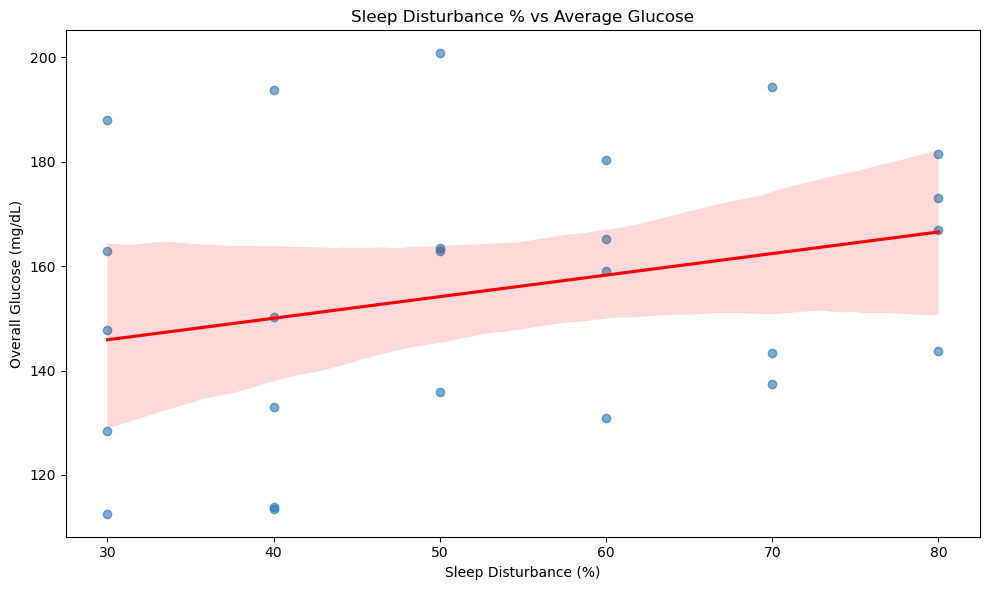

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.regplot(
    data=merged,
    x='avg_sleep_disturbance',
    y='avg_glucose',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title("Sleep Disturbance % vs Average Glucose")
plt.xlabel("Sleep Disturbance (%)")
plt.ylabel("Overall Glucose (mg/dL)")
plt.tight_layout()
plt.show()


****Insights:****





In [53]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

def sleep_intervention(disturbance_pct):
    if disturbance_pct > 50:
        return (
            "Severe sleep disturbance: "
            "1. Fixed sleep/wake schedule, "
            "2. No screens 1 hr before bed, "
            "3. Review nighttime glucose & insulin timing, "
            "4. Screen for sleep apnea, "
            "5. Manage Stress/Anxiety."
        )
    elif disturbance_pct > 30:
        return (
            "Moderate sleep disturbance: "
            "1. Improve sleep schedule, "
            "2. Reduce late caffeine & meals, "
            "3. Review late bolus timing, "
            "4. Relaxation before bed."
        )
    else:
        return (
            "Mild disturbance: Reinforce good sleep habits and monitor."
        )

df_sleep['intervention'] = df_sleep['%_With_Sleep_Disturbances'].apply(sleep_intervention)
df_sleep[['Patient_Id', '%_With_Sleep_Disturbances', 'intervention']].head(10)


,Patient_Id,%_With_Sleep_Disturbances,intervention
0,HUPA0001P,80,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
1,HUPA0002P,40,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
2,HUPA0003P,70,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
3,HUPA0004P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
4,HUPA0005P,30,Mild disturbance: Reinforce good sleep habits and monitor.
5,HUPA0006P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
6,HUPA0007P,80,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."
7,HUPA0009P,40,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
8,HUPA0010P,50,"Moderate sleep disturbance: 1. Improve sleep schedule, 2. Reduce late caffeine & meals, 3. Review late bolus timing, 4. Relaxation before bed."
9,HUPA0011P,60,"Severe sleep disturbance: 1. Fixed sleep/wake schedule, 2. No screens 1 hr before bed, 3. Review nighttime glucose & insulin timing, 4. Screen for sleep apnea, 5. Manage Stress/Anxiety."


****Insights:****




### 3. What is the correlation between Basal rate and glucose levels and what recommendations can be given with regard to basal rate for patients with high glucose levels

In [9]:
df['Time'] = pd.to_datetime(df['Time'], format='mixed')

In [10]:
df['Hour'] = df['Time'].dt.hour
df['Date'] = df['Time'].dt.date

In [11]:
# Day wise average of fasting glucose and Basal Rate #

fasting = (
    df[(df['Hour'] >= 5) & (df['Hour'] <= 7)]
    .groupby(['Patient_Id', 'Date'])
    .agg(fasting_glucose=('Glucose', 'mean'))
    .reset_index()
)

In [12]:
daily_basal = (
    df.groupby(['Patient_Id', 'Date'])
      .agg(avg_basal=('Basal_Rate', 'mean'))
      .reset_index()
)


In [13]:
daily_metrics = fasting.merge(daily_basal, on=['Patient_Id', 'Date'])

In [14]:
corr = daily_metrics['avg_basal'].corr(daily_metrics['fasting_glucose'])
print("Correlation between basal rate and fasting glucose:", corr)


Correlation between basal rate and fasting glucose: -0.06813140255661045


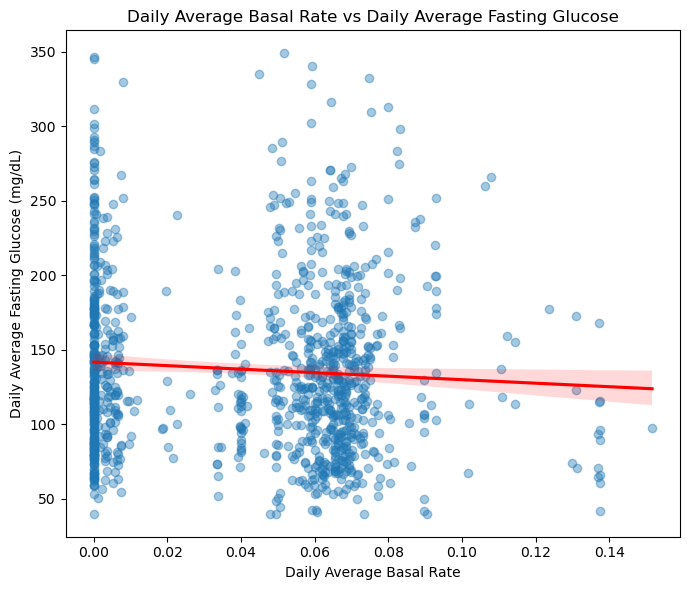

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.regplot(
    data=daily_metrics,
    x='avg_basal',
    y='fasting_glucose',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)

plt.title("Daily Average Basal Rate vs Daily Average Fasting Glucose")
plt.xlabel("Daily Average Basal Rate")
plt.ylabel("Daily Average Fasting Glucose (mg/dL)")
plt.tight_layout()
plt.show()


In [16]:
def basal_fasting_pattern(row):
    if row['fasting_glucose'] > 130 and row['avg_basal'] < daily_metrics['avg_basal'].median():
        return "High fasting + lower basal: pattern suggests insufficient overnight insulin effect"
    elif row['fasting_glucose'] < 90 and row['avg_basal'] > daily_metrics['avg_basal'].median():
        return "Lower fasting + higher basal: pattern suggests stronger overnight insulin effect"
    elif row['fasting_glucose'] > 130:
        return "Elevated fasting glucose observed"
    else:
        return "Fasting glucose within typical range"

daily_metrics['pattern_insight'] = daily_metrics.apply(basal_fasting_pattern, axis=1)


In [17]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

daily_metrics[['Patient_Id', 'Date', 'avg_basal', 'fasting_glucose', 'pattern_insight']]


,Patient_Id,Date,avg_basal,fasting_glucose,pattern_insight
0,HUPA0001P,2018-06-14,0.046146,80.444444,Fasting glucose within typical range
1,HUPA0001P,2018-06-15,0.051736,136.444444,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
2,HUPA0001P,2018-06-16,0.050174,133.277778,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
3,HUPA0001P,2018-06-17,0.054583,132.055556,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
4,HUPA0001P,2018-06-18,0.049097,115.083333,Fasting glucose within typical range
...,...,...,...,...,...
1066,HUPA0028P,2022-05-14,0.000000,65.472222,Fasting glucose within typical range
1067,HUPA0028P,2022-05-15,0.000000,129.250000,Fasting glucose within typical range
1068,HUPA0028P,2022-05-16,0.001667,141.555556,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
1069,HUPA0028P,2022-05-17,0.038333,147.111111,High fasting + lower basal: pattern suggests insufficient overnight insulin effect
